In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

In [5]:
data = pd.read_csv("transactions.csv")
data.head()

,accountNumber,creditLimit,availableMoney,transactionDateTime,merchantName,transactionAmount,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud
0,737265056,5000,5000.0,2016-08-13T14:27:32,Uber,98.55,US,US,2.0,1.0,...,3/14/2015,3/14/2015,414,414,1803,PURCHASE,0.0,0,0,0
1,737265056,5000,5000.0,2016-10-11T05:05:54,AMC #191138,74.51,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.0,1,0,0
2,737265056,5000,5000.0,2016-11-08T09:18:39,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.0,0,0,0
3,737265056,5000,5000.0,2016-12-10T02:14:50,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.0,0,0,0
4,830329091,5000,5000.0,2016-03-24T21:04:46,Tim Hortons #947751,71.18,US,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.0,1,0,0


In [6]:
print(data.shape)
data.info()

(786363, 22)
<class 'pandas.DataFrame'>
RangeIndex: 786363 entries, 0 to 786362
Data columns (total 22 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   accountNumber             786363 non-null  int64  
 1   creditLimit               786363 non-null  int64  
 2   availableMoney            786363 non-null  float64
 3   transactionDateTime       786363 non-null  str    
 4   merchantName              786363 non-null  str    
 5   transactionAmount         786363 non-null  float64
 6   acqCountry                781801 non-null  str    
 7   merchantCountryCode       785639 non-null  str    
 8   posEntryMode              782309 non-null  float64
 9   posConditionCode          785954 non-null  float64
 10  merchantCategoryCode      786363 non-null  str    
 11  currentExpDate            786363 non-null  str    
 12  accountOpenDate           786363 non-null  str    
 13  dateOfLastAddressChange   786363 non-null 

In [7]:
data.isnull().sum()

accountNumber                  0
creditLimit                    0
availableMoney                 0
transactionDateTime            0
merchantName                   0
transactionAmount              0
acqCountry                  4562
merchantCountryCode          724
posEntryMode                4054
posConditionCode             409
merchantCategoryCode           0
currentExpDate                 0
accountOpenDate                0
dateOfLastAddressChange        0
cardCVV                        0
enteredCVV                     0
cardLast4Digits                0
transactionType              698
currentBalance                 0
cardPresent                    0
expirationDateKeyInMatch       0
isFraud                        0
dtype: int64

In [8]:
print(data.columns)

Index(['accountNumber', 'creditLimit', 'availableMoney', 'transactionDateTime',
       'merchantName', 'transactionAmount', 'acqCountry',
       'merchantCountryCode', 'posEntryMode', 'posConditionCode',
       'merchantCategoryCode', 'currentExpDate', 'accountOpenDate',
       'dateOfLastAddressChange', 'cardCVV', 'enteredCVV', 'cardLast4Digits',
       'transactionType', 'currentBalance', 'cardPresent',
       'expirationDateKeyInMatch', 'isFraud'],
      dtype='str')


In [9]:
data.head()

,accountNumber,creditLimit,availableMoney,transactionDateTime,merchantName,transactionAmount,acqCountry,merchantCountryCode,posEntryMode,posConditionCode,...,accountOpenDate,dateOfLastAddressChange,cardCVV,enteredCVV,cardLast4Digits,transactionType,currentBalance,cardPresent,expirationDateKeyInMatch,isFraud
0,737265056,5000,5000.0,2016-08-13T14:27:32,Uber,98.55,US,US,2.0,1.0,...,3/14/2015,3/14/2015,414,414,1803,PURCHASE,0.0,0,0,0
1,737265056,5000,5000.0,2016-10-11T05:05:54,AMC #191138,74.51,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.0,1,0,0
2,737265056,5000,5000.0,2016-11-08T09:18:39,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.0,0,0,0
3,737265056,5000,5000.0,2016-12-10T02:14:50,Play Store,7.47,US,US,9.0,1.0,...,3/14/2015,3/14/2015,486,486,767,PURCHASE,0.0,0,0,0
4,830329091,5000,5000.0,2016-03-24T21:04:46,Tim Hortons #947751,71.18,US,US,2.0,1.0,...,8/6/2015,8/6/2015,885,885,3143,PURCHASE,0.0,1,0,0


In [10]:
data["isFraud"].value_counts()

isFraud
0    773946
1     12417
Name: count, dtype: int64

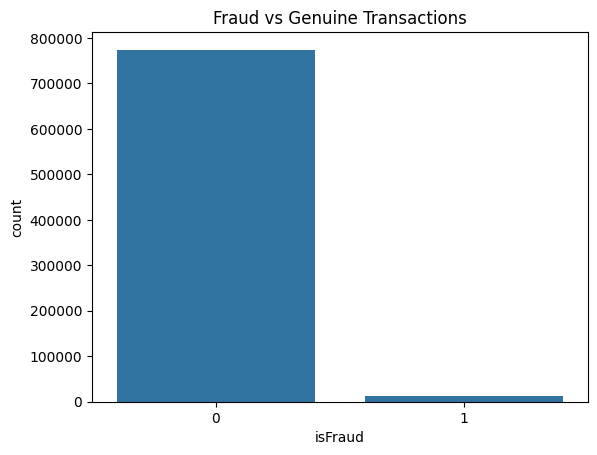

In [11]:
sns.countplot(x="isFraud", data=data)
plt.title("Fraud vs Genuine Transactions")
plt.show()

In [12]:
data.isnull().sum()

accountNumber                  0
creditLimit                    0
availableMoney                 0
transactionDateTime            0
merchantName                   0
transactionAmount              0
acqCountry                  4562
merchantCountryCode          724
posEntryMode                4054
posConditionCode             409
merchantCategoryCode           0
currentExpDate                 0
accountOpenDate                0
dateOfLastAddressChange        0
cardCVV                        0
enteredCVV                     0
cardLast4Digits                0
transactionType              698
currentBalance                 0
cardPresent                    0
expirationDateKeyInMatch       0
isFraud                        0
dtype: int64

In [13]:
data = data.dropna()

In [14]:
features = [
    "creditLimit",
    "availableMoney",
    "transactionAmount",
    "currentBalance",
    "cardPresent",
    "posEntryMode",
    "posConditionCode",
    "expirationDateKeyInMatch"
]
X = data[features]
y = data["isFraud"]

In [15]:
X["cardPresent"] = X["cardPresent"].astype(int)
X["expirationDateKeyInMatch"] = (
    X["expirationDateKeyInMatch"].astype(int)
)

In [16]:
X = X.fillna(0)

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [19]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [20]:
print(y_train.value_counts())

print(y_train_smote.value_counts())

isFraud
0    611761
1      9573
Name: count, dtype: int64
isFraud
1    611761
0    611761
Name: count, dtype: int64


In [21]:
log_model = LogisticRegression()
log_model.fit(X_train_smote, y_train_smote)
log_pred = log_model.predict(X_test)

In [22]:
print("Accuracy:",
      accuracy_score(y_test, log_pred))
print("Precision:",
      precision_score(y_test, log_pred))
print("Recall:",
      recall_score(y_test, log_pred))
print("F1 Score:",
      f1_score(y_test, log_pred))

Accuracy: 0.6932802863507024
Precision: 0.030425668804350083
Recall: 0.6126201420810697
F1 Score: 0.057972160708636505


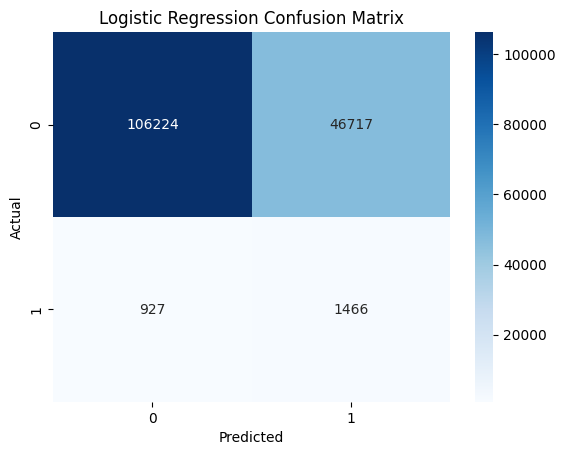

In [23]:
cm = confusion_matrix(y_test, log_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [24]:
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.99      0.69      0.82    152941
           1       0.03      0.61      0.06      2393

    accuracy                           0.69    155334
   macro avg       0.51      0.65      0.44    155334
weighted avg       0.98      0.69      0.81    155334



In [25]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    log_pred
).ravel()
loss = fp + 25 * fn
print("False Positives:", fp)
print("False Negatives:", fn)
print("Investigation Loss:", loss)

False Positives: 46717
False Negatives: 927
Investigation Loss: 69892


In [27]:
tree_model = DecisionTreeClassifier(
    random_state=42
)
tree_model.fit(
    X_train_smote,
    y_train_smote
)
tree_pred = tree_model.predict(X_test)

In [28]:
print("Accuracy:",
      accuracy_score(y_test, tree_pred))
print("Precision:",
      precision_score(y_test, tree_pred))
print("Recall:",
      recall_score(y_test, tree_pred))
print("F1 Score:",
      f1_score(y_test, tree_pred))

Accuracy: 0.8749146999369102
Precision: 0.024875899380891294
Recall: 0.1863769327204346
F1 Score: 0.043893317586851686


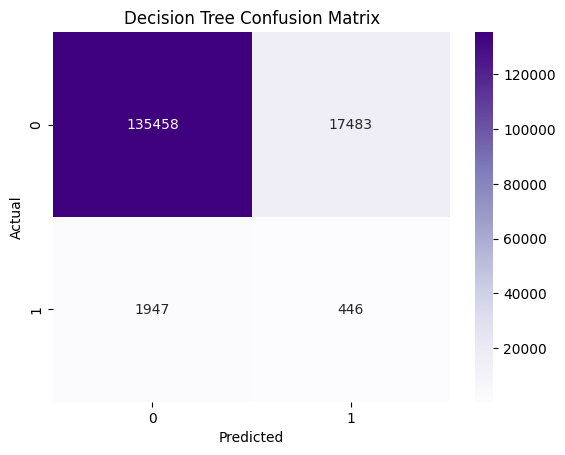

In [29]:
cm = confusion_matrix(y_test, tree_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Purples"
)
plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [30]:
print(classification_report(
    y_test,
    tree_pred
))

              precision    recall  f1-score   support

           0       0.99      0.89      0.93    152941
           1       0.02      0.19      0.04      2393

    accuracy                           0.87    155334
   macro avg       0.51      0.54      0.49    155334
weighted avg       0.97      0.87      0.92    155334



In [31]:
tn, fp, fn, tp = confusion_matrix(
    y_test,
    tree_pred
).ravel()

loss = fp + 25 * fn

print("False Positives:", fp)

print("False Negatives:", fn)

print("Investigation Loss:", loss)

False Positives: 17483
False Negatives: 1947
Investigation Loss: 66158


In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
rf_model.fit(
    X_train_smote,
    y_train_smote
)
rf_pred = rf_model.predict(X_test)

In [35]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree"
    ],
    
    "Investigation Loss": [
        69892,
        66158
    ]
})

results

,Model,Investigation Loss
0,Logistic Regression,69892
1,Decision Tree,66158
